In [1]:
import numpy as np
import os, sys 
import ROOT
from cats.cdataframe import CDataFrame
import glob

import matplotlib.pyplot as plt
%matplotlib inline

CDMS = os.environ["CDMS"] # set in .bash_profile
stylesheet = os.path.join(CDMS,"scripts","stylesheets","blues.mplstyle")
plt.style.use(stylesheet)

sys.path.append(os.path.join(os.path.join(CDMS,"scripts")))
import setup

Welcome to JupyROOT 6.28/10


In [2]:
path = '/scratch/user/perry5334/samples/DMC_SNOLAB_HV/CUTE_Cf252calib_source/DMCOutput_EmptyEvents_Spectrum/'
DMCfiles = np.sort(glob.glob(path + f'CUTE_Cf252_????????_??????.root'))
det = 1

In [3]:
mczipFrame = CDataFrame(f"G4SimDir/mczip{det}", DMCfiles)
mczip = mczipFrame.AsNumpy(['EventNum', 'PName', 'Edep', 'Parent', 'Track'])
mcDecaysFrame = CDataFrame("G4SimDir/mcDecays", DMCfiles)
mcDecays = mcDecaysFrame.Filter(f'DetNum=={det}').AsNumpy(['EventNum', 'PName', 'KE', 'Parent', 'Track'])
#mceventFrame = CDataFrame(f"G4SimDir/mcevent", DMCfiles)
#mcevent = mceventFrame.AsNumpy(['EventNum', 'ZipsHit'])

# Save array of events where neutron capture and Ge71 activation occurred. Determined by recoil/decay of Ga71 nucleus.
GeActivEvents = np.unique(mczipFrame.Filter('string(PName.data()) == "Ga71"').AsNumpy(['EventNum'])['EventNum'])
#GeActivEventsmcDecays = np.unique(mcDecaysFrame.Filter(f'DetNum=={det}').Filter('string(PName.data()) == "Ga71"').AsNumpy(['EventNum'])['EventNum'])

In [5]:
# Select events in mczip and mcDecays which correspond to Ge activation
mcDecaysEventMask = np.isin(mcDecays['EventNum'], GeActivEvents)
mczipEventMask = np.isin(mczip['EventNum'], GeActivEvents)

# Process Ge activation data from mcDecays tree
for key in list(mcDecays.keys()):
    mcDecays[key] = mcDecays[key][mcDecaysEventMask]

mcDecays['KEsum'] = np.array([mcDecays['KE'][mcDecays['EventNum'] == event].sum() for event in GeActivEvents])

# Process Ge activation data from mczip tree
for key in list(mczip.keys()):
    mczip[key] = mczip[key][mczipEventMask]

mczip['Edepsum'] = np.array([mczip['Edep'][mczip['EventNum'] == event].sum() for event in GeActivEvents])

Text(0, 1, 'Count / (0.12 keV)')

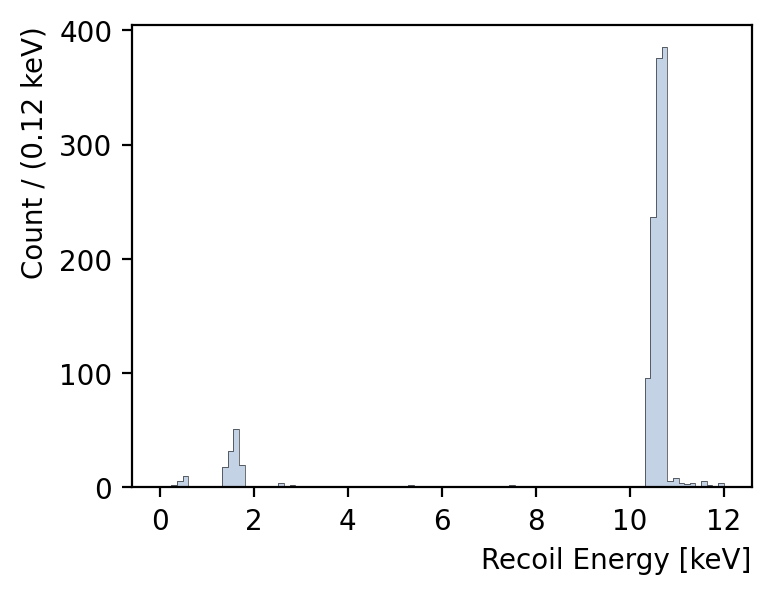

In [6]:
plt.figure(figsize=(4,3), dpi=200)
plt.hist(mczip['Edepsum']*1e-3, bins = np.linspace(0, 12, 101), alpha = 0.75)
plt.hist(mczip['Edepsum']*1e-3, bins = np.linspace(0, 12, 101), histtype='step', color = 'black', lw = 0.2)

plt.xlabel('Recoil Energy [keV]')
plt.ylabel('Count / (0.12 keV)')

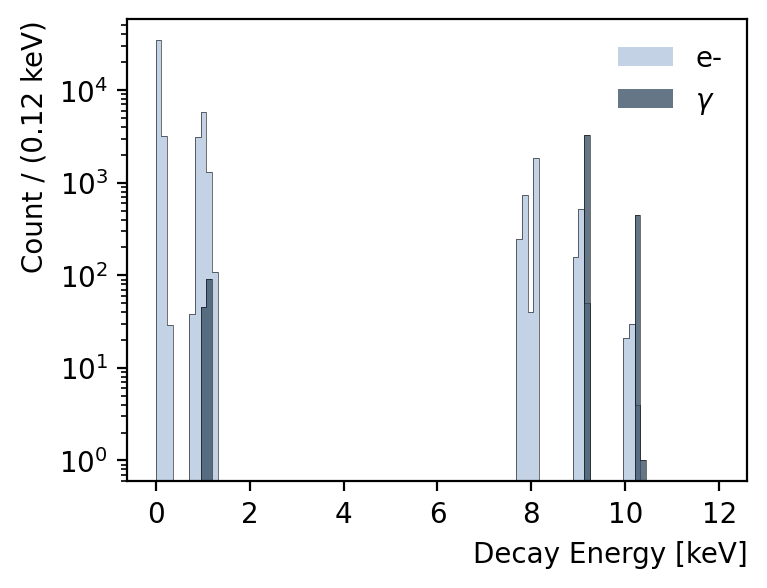

In [7]:
plt.figure(figsize=(4,3), dpi=200)
plt.hist(mcDecays['KE'][mcDecays['PName'] == 'e-']*1e-3, bins = np.linspace(0, 12, 101), alpha = 0.75, zorder = 0, label = 'e-', color = 'C0')
plt.hist(mcDecays['KE'][mcDecays['PName'] == 'e-']*1e-3, bins = np.linspace(0, 12, 101), histtype='step', color = 'black', lw = 0.2, zorder = 1)
plt.hist(mcDecays['KE'][mcDecays['PName'] == 'gamma']*1e-3, bins = np.linspace(0, 12, 101), alpha = 0.75, zorder = 2, label = r'$\gamma$', color = 'C1')
plt.hist(mcDecays['KE'][mcDecays['PName'] == 'gamma']*1e-3, bins = np.linspace(0, 12, 101), histtype='step', color = 'black', lw = 0.2, zorder = 3)

plt.xlabel('Decay Energy [keV]')
plt.ylabel('Count / (0.12 keV)')
plt.yscale('log')
plt.legend()

Text(0, 1, 'Count / (0.12 keV)')

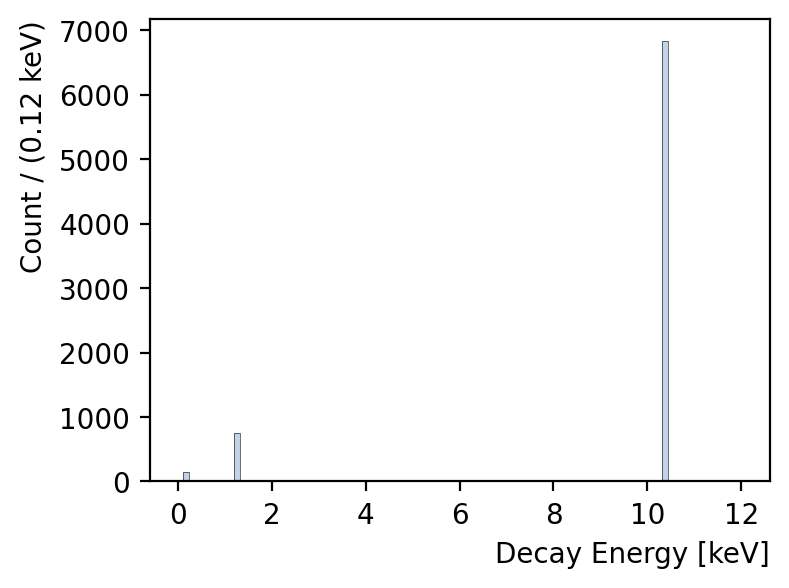

In [8]:
plt.figure(figsize=(4,3), dpi=200)
plt.hist(mcDecays['KEsum']*1e-3, bins = np.linspace(0, 12, 101), alpha = 0.75)
plt.hist(mcDecays['KEsum']*1e-3, bins = np.linspace(0, 12, 101), histtype='step', color = 'black', lw = 0.2)

plt.xlabel('Decay Energy [keV]')
plt.ylabel('Count / (0.12 keV)')

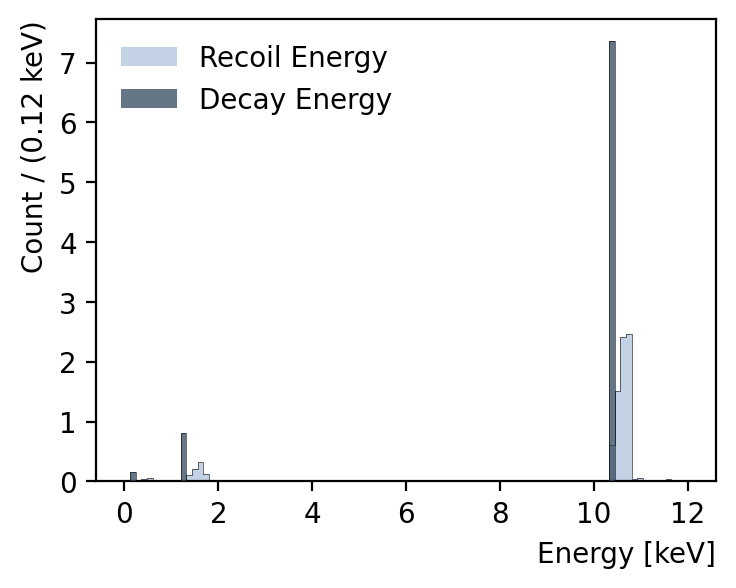

In [9]:
plt.figure(figsize=(4,3), dpi=200)
plt.hist(mczip['Edepsum']*1e-3, bins = np.linspace(0, 12, 101), density=True, label = 'Recoil Energy', color = 'C0', zorder = 1, alpha = 0.75)
plt.hist(mczip['Edepsum']*1e-3, bins = np.linspace(0, 12, 101), histtype='step', color = 'black', lw = 0.2, density=True, zorder = 2)
plt.hist(mcDecays['KEsum']*1e-3, bins = np.linspace(0, 12, 101), density=True, label = 'Decay Energy', color = 'C1', zorder = 3, alpha = 0.75)
plt.hist(mcDecays['KEsum']*1e-3, bins = np.linspace(0, 12, 101), histtype='step', color = 'black', lw = 0.2, density=True, zorder = 4)

plt.xlabel('Energy [keV]')
plt.ylabel('Count / (0.12 keV)')
plt.legend()

Text(0, 1, 'Count')

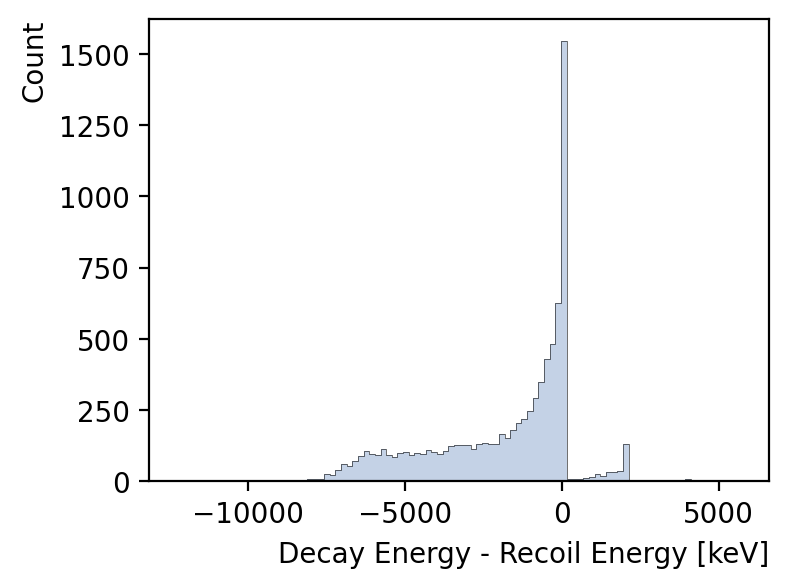

In [12]:
plt.figure(figsize=(4,3), dpi=200)
plt.hist((mcDecays['KEsum']-mczip['Edepsum'])*1e-3, bins = 100, alpha = 0.75)
plt.hist((mcDecays['KEsum']-mczip['Edepsum'])*1e-3, bins = 100, histtype='step', color = 'black', lw = 0.2)

plt.xlabel('Decay Energy - Recoil Energy [keV]')
plt.ylabel('Count')

In [27]:
(mcDecays['KEsum']-mczip['Edepsum']).tolist().index(max(mcDecays['KEsum']-mczip['Edepsum']))

4339

In [30]:
(mcDecays['KEsum']-mczip['Edepsum']).tolist().index(min(mcDecays['KEsum']-mczip['Edepsum']))

5390

In [41]:
eventIndex = 4339
print(f'Looking at Ge activation event index {eventIndex}')
print('which has the maximum KE - Edep difference')

mcDecays_eventCut = mcDecays['EventNum'] == GeActivEvents[eventIndex]
mczip_eventCut = mczip['EventNum'] == GeActivEvents[eventIndex]

mcDecays_PName = mcDecays['PName'][mcDecays_eventCut]
mczip_PName = mczip['PName'][mczip_eventCut]

mcDecays_KE = mcDecays['KE'][mcDecays_eventCut]
mczip_Edep = mczip['Edep'][mczip_eventCut]
print(f'of {sum(mcDecays_KE) - sum(mczip_Edep)} eV')
print()

print(f'mcDecays.PName with corresponding mcDecays.KE for this event are as follows:')
for entry in range(len(mcDecays_PName)):
    print(f'{mcDecays_PName[entry]} -> {np.round(mcDecays_KE[entry])} eV')
print(f'-------------------------------------')
print(f'with a total of {np.round(sum(mcDecays_KE))} eV')
print()

print(f'mczip.PName with corresponding mczip.Edep for this event are as follows:')
for entry in range(len(mczip_PName)):
    print(f'{mczip_PName[entry]} -> {np.round(mczip_Edep[entry])} eV')
print(f'-------------------------------------')
print(f'with a total of {np.round(sum(mczip_Edep))} eV')

Looking at Ge activation event index 4339
which has the maximum KE - Edep difference
of 5715387.255802436 eV

mcDecays.PName with corresponding mcDecays.KE for this event are as follows:
Ga71 -> 0.0 eV
e- -> 29.0 eV
e- -> 1096.0 eV
e- -> 57.0 eV
e- -> 17.0 eV
e- -> 11.0 eV
e- -> 80.0 eV
alpha -> 1930658.0 eV
Hg200 -> 38652.0 eV
alpha -> 1930658.0 eV
Hg200 -> 38652.0 eV
alpha -> 1930658.0 eV
Hg200 -> 38652.0 eV
alpha -> 1930658.0 eV
Hg200 -> 38652.0 eV
-------------------------------------
with a total of 7878531.0 eV

mczip.PName with corresponding mczip.Edep for this event are as follows:
Ge71 -> 219.0 eV
gamma -> 12.0 eV
e- -> 18.0 eV
e- -> 9.0 eV
e- -> 133038.0 eV
e- -> 25867.0 eV
e- -> 145160.0 eV
e- -> 101866.0 eV
e- -> 97320.0 eV
e- -> 96083.0 eV
e- -> 63650.0 eV
e- -> 105282.0 eV
e- -> 49187.0 eV
e- -> 82444.0 eV
e- -> 36030.0 eV
e- -> 35431.0 eV
e- -> 29493.0 eV
e- -> 36958.0 eV
e- -> 37620.0 eV
e- -> 51140.0 eV
e- -> 8797.0 eV
gamma -> 14.0 eV
e- -> 48.0 eV
e- -> 26.0 eV
e- ->

In [40]:
eventIndex = 5390
print(f'Looking at Ge activation event index {eventIndex}')
print('which has the minimum KE - Edep difference')

mcDecays_eventCut = mcDecays['EventNum'] == GeActivEvents[eventIndex]
mczip_eventCut = mczip['EventNum'] == GeActivEvents[eventIndex]

mcDecays_PName = mcDecays['PName'][mcDecays_eventCut]
mczip_PName = mczip['PName'][mczip_eventCut]

mcDecays_KE = mcDecays['KE'][mcDecays_eventCut]
mczip_Edep = mczip['Edep'][mczip_eventCut]
print(f'of {sum(mcDecays_KE) - sum(mczip_Edep)} eV')
print()

print(f'mcDecays.PName with corresponding mcDecays.KE for this event are as follows:')
for entry in range(len(mcDecays_PName)):
    print(f'{mcDecays_PName[entry]} -> {np.round(mcDecays_KE[entry])} eV')
print(f'-------------------------------------')
print(f'with a total of {np.round(sum(mcDecays_KE))} eV')
print()

print(f'mczip.PName with corresponding mczip.Edep for this event are as follows:')
for entry in range(len(mczip_PName)):
    print(f'{mczip_PName[entry]} -> {np.round(mczip_Edep[entry])} eV')
print(f'-------------------------------------')
print(f'with a total of {np.round(sum(mczip_Edep))} eV')

Looking at Ge activation event index 5390
which has the minimum KE - Edep difference
of -12225459.537257057 eV

mcDecays.PName with corresponding mcDecays.KE for this event are as follows:
Ga71 -> 0.0 eV
e- -> 9102.0 eV
e- -> 907.0 eV
e- -> 75.0 eV
e- -> 54.0 eV
e- -> 54.0 eV
e- -> 11.0 eV
e- -> 129.0 eV
-------------------------------------
with a total of 10331.0 eV

mczip.PName with corresponding mczip.Edep for this event are as follows:
Ge71 -> 111679.0 eV
Ge74 -> 0.0 eV
e- -> 235265.0 eV
e- -> 253416.0 eV
e+ -> 711777.0 eV
e- -> 399340.0 eV
e+ -> 369620.0 eV
e- -> 630582.0 eV
e+ -> 375484.0 eV
e- -> 303020.0 eV
e- -> 296917.0 eV
e+ -> 337819.0 eV
e- -> 236785.0 eV
e- -> 123924.0 eV
e- -> 168191.0 eV
e- -> 98383.0 eV
e+ -> 250069.0 eV
e- -> 83260.0 eV
e- -> 87677.0 eV
e- -> 40689.0 eV
e- -> 42836.0 eV
e- -> 51771.0 eV
e- -> 67043.0 eV
e- -> 32661.0 eV
e- -> 36277.0 eV
e- -> 42977.0 eV
e+ -> 289865.0 eV
e- -> 20662.0 eV
e- -> 38597.0 eV
e- -> 26419.0 eV
gamma -> 110.0 eV
e- -> 17.0 